In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
conn = sqlite3.connect("../database/ecommerce.db")
customers = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)
products = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)
orders = pd.read_csv("../data/Orders.csv")
payments = pd.read_csv("../data/Payments.csv")
merged = orders.merge(
    products,
    on="product_id"
)
merged["revenue"] = (
    merged["quantity"] *
    merged["price"]
)
merged["order_date"] = pd.to_datetime(
    merged["order_date"]
)
merged["month_name"] = (
    merged["order_date"]
    .dt.month_name()
)
merged["day_name"] = (
    merged["order_date"]
    .dt.day_name()
)

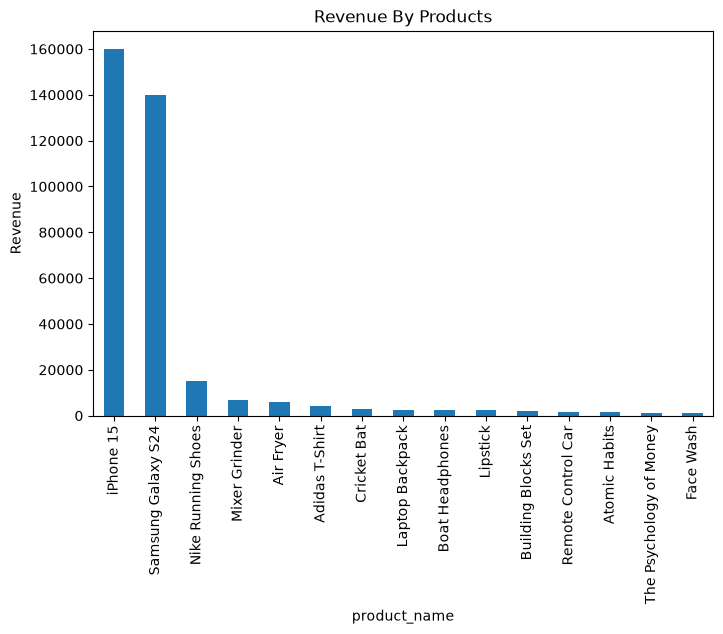

In [21]:
plt.figure(figsize=(8,5))
product_revenue= (
    merged.groupby("product_name")["revenue"].sum().sort_values(ascending=False)
)
product_revenue.plot(kind="bar")
plt.title("Revenue By Products")
plt.ylabel("Revenue")
plt.show()

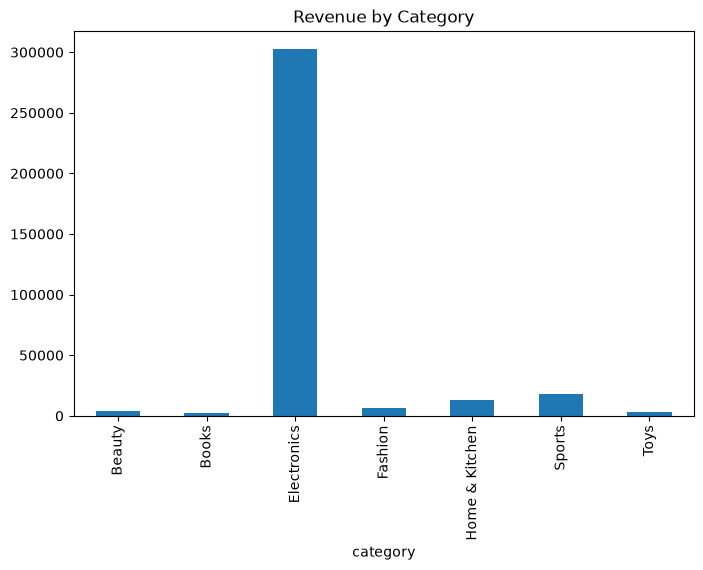

In [20]:
plt.figure(figsize=(8,5))
category_revenue = (
    merged.groupby("category")["revenue"].sum()
)
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.show()

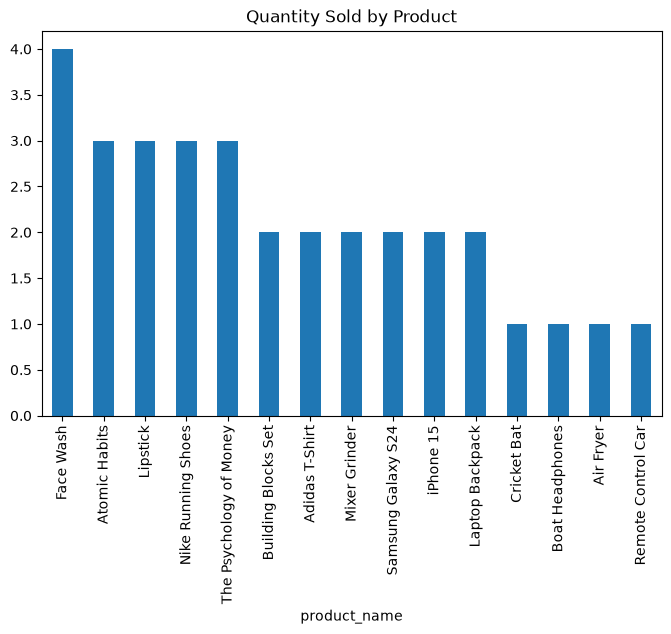

In [19]:
plt.figure(figsize=(8,5))
best_selling = (
    merged.groupby("product_name")["quantity"].sum().sort_values(ascending=False)
)
best_selling.plot(kind="bar")
plt.title("Quantity Sold by Product")
plt.show()

In [5]:
daily_revenue = (
    merged.groupby("day_name")["revenue"].sum()
)

In [6]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_revenue = daily_revenue.reindex(day_order)

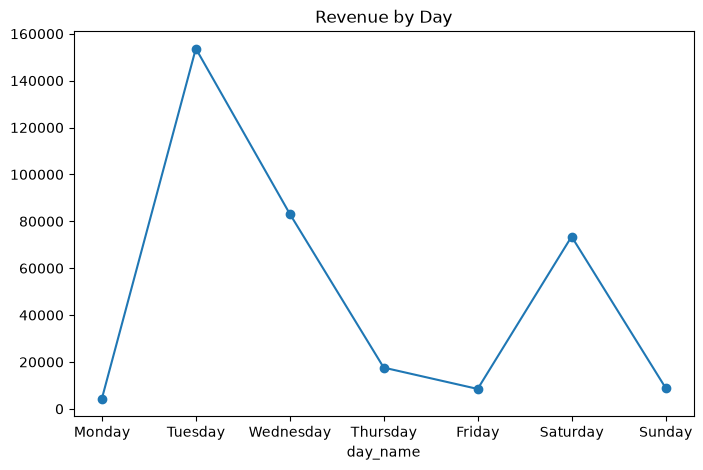

In [18]:
plt.figure(figsize=(8,5))
daily_revenue.plot(
    kind="line",
    marker="o"
)
plt.title("Revenue by Day")
plt.show()

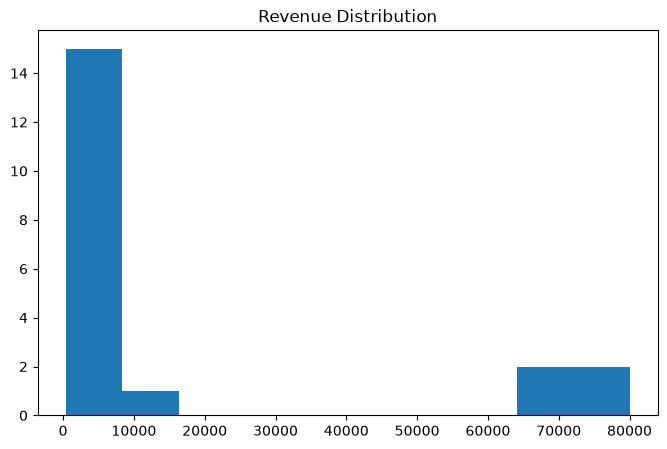

In [17]:
plt.figure(figsize=(8,5))
plt.hist(
    merged["revenue"],
    bins=10
)
plt.title(
    "Revenue Distribution"
)
plt.show()

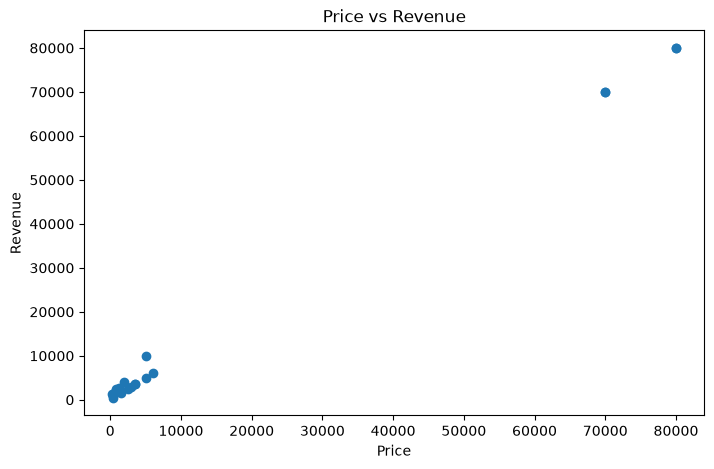

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(
    merged["price"],
    merged["revenue"]
)
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title(
    "Price vs Revenue"
)
plt.show()

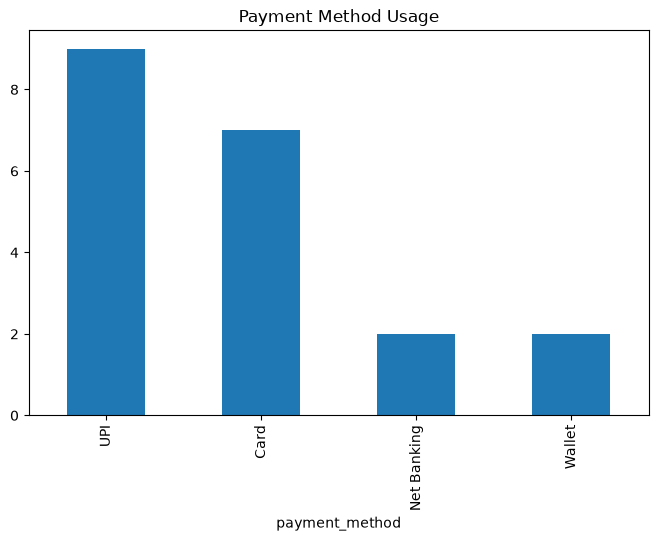

In [15]:
plt.figure(figsize=(8,5))
payment_data = orders.merge(
    payments,
    on="order_id"
)
payment_method_count = (
    payment_data["payment_method"]
    .value_counts()
)
payment_method_count.plot(
    kind="bar"
)
plt.title(
    "Payment Method Usage"
)
plt.show()

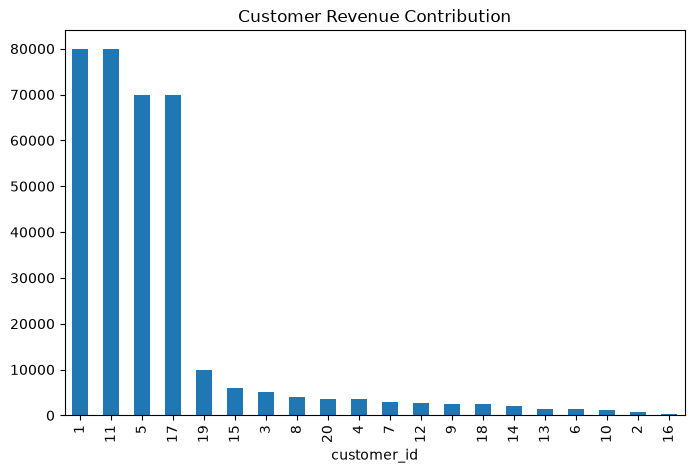

In [14]:
plt.figure(figsize=(8,5))
customer_revenue = (
    merged.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)
customer_revenue.plot(
    kind="bar"
)
plt.title(
    "Customer Revenue Contribution"
)
plt.show()

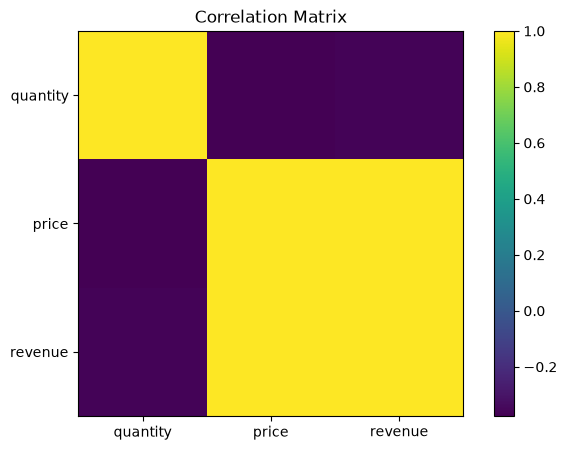

In [13]:
plt.figure(figsize=(8,5))
corr = merged[
    ["quantity","price","revenue"]
].corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Correlation Matrix"
)

plt.show()